# Lesson 07a: SchNet and continuous-filter convolution

**What you will learn**

- Why *distance-only* features make a network invariant under rotations,
  translations and parity, and what the pros and cons of this design choice are.
- The **continuous-filter convolution** (cfconv), SchNet's core operation, and
  its filter-generating network.
- How SchNet is assembled: atom-type embedding $\to$ interaction blocks $\to$
  filter MLP $\to$ element-wise product $\to$ atom-wise layers $\to$ atom-wise
  energy readout.
- Why **energy-conserving forces** must come from $\vec F_i = -\partial E /
  \partial \vec r_i$ (e.g., using autograd), and not from a separate force head.
- Training on energies **and** forces with the standard weighted loss. We will
  verify the invariance of $E$ and covariance of $\vec F$ numerically.

**Prerequisites:**

- [Lesson 01a](01a_symmetry_and_equivariance.ipynb): Invariance vs. equivariance,
- [Lesson 05a](05a_atomistic_graphs.ipynb): Atomistic graphs,
- [Lesson 05b](05b_radial_bases_and_cutoffs.ipynb): Radial bases and cutoffs.

In [1]:
import sys; sys.path.insert(0, "..")

import copy, time, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from course_utils.data import make_lj_argon_dataset, train_val_split, radius_graph
from course_utils.plotting import plot_training_curves
from course_utils.equivariance import assert_model_equivariant

warnings.filterwarnings("ignore", category=FutureWarning)  # ASE Langevin deprecation notice
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}, torch {torch.__version__}")

device = cuda, torch 2.7.1+cu126


## Why an invariant baseline?

This lesson builds our first complete **machine learning potential**: a neural
network that takes an atomistic configuration, nuclear charges and positions
$\{(Z_i, \vec r_i)\}_{i=1}^{n}$,  and predicts its total energy $\hat E$, from
which the forces follow by differentiation. We begin by focusing on the
**SchNet** ar chitecture, which we implement from scratch and train on frames of
a molecular-dynamics trajectory of Lennard-Jones argon.

A potential energy is not an arbitrary function of the positions: rigidly
translating, rotating, or reflecting an isolated system leaves its energy
unchanged. Therefore, $\hat E$ must be **invariant under the Euclidean group
$E(3)$** operations. 

In Parts I-II of this course, we have built the machinery for the general
solution: networks whose internal features transform under rotations (rotational
equivariance), and Part IV will use it to construct $E(3)$-equivariant
potentials. Before that, we should study older, yet strong, alternatives:
architectures that acquire invariance by *restricting their inputs*, throwing
away all directional information and keeping only the **interatomic distances**.

To see why distances suffice, let us consider a rigid motion plus possible
reflection acting on all positions, $\vec r_i \mapsto R\,\vec r_i + \vec t$ with
$R \in O(3)$ (so $R^\top R = I$, $\det R = \pm 1$. The $-1$ case corresponds to
the parity/inversion operation) and $\vec t \in \mathbb{R}^3$. The pairwise
atomic distances remain unchanged under this transformation:

$$
d_{ij} = \lVert \vec r_i - \vec r_j \rVert
\;\longmapsto\;
\lVert (R\vec r_i + \vec t) - (R\vec r_j + \vec t) \rVert
= \lVert R(\vec r_i - \vec r_j) \rVert
= \lVert \vec r_i - \vec r_j \rVert = d_{ij},
$$

because $\lVert R\vec v\rVert^2 = \vec v^\top R^\top R\, \vec v = \lVert\vec
v\rVert^2$ for **any** orthogonal $R$ including rotations and reflections. As
such,

> Any function of atom types and distances $\{Z_i, d_{ij}\}$ is automatically
invariant under the **full Euclidean group, E(3)**, including parity.
Consequently, the force (the gradient of the energy) becomes automatically
equivariant.

This is the core design principle in SchNet: invariance is obtained *by
restricting the inputs*, not by representation theory. An obvious drawback of
distance-only models is that they are blind to angles and chirality within a
cutoff: Lesson 07b shows that distance-only models such as SchNet are incomplete
and cannot even distinguish certain environments, motivating Part IV of this
course.

## The continuous-filter convolution (cfconv)

A discrete convolution slides a filter *tensor* over a grid of positions. In
reality, atoms in a molecule or crystal often do not sit on a grid. So, SchNet
replaces the filter tensor by a **filter-generating function**, $W^l :
\mathbb{R}^D \to \mathbb{R}^F$, evaluated at each relative position. With atom
features, $x_i^l \in \mathbb{R}^F$ at layer $l$ (and feature dimension, $F$),
the layer output can be expressed as:

$$
x_i^{l+1} = \big(X^l * W^l\big)_i = \sum_j x_j^l \odot W^l(\vec r_i - \vec r_j),
$$

where $\odot$ is **element-wise** multiplication (compared to the convolution,
which acts feature-wise and mixes the feature channels. This operation is
assigned to separate atom-wise layers and will be discussed later in this
lesson).

### Restriction to distances

In order to make the energy rotationally invariant, SchNet restricts the filter
to depend only on the interatomic distance:

$$
W^l(\vec r_i - \vec r_j) \;=\; W^l\!\big(d_{ij}\big), \qquad d_{ij} = \lVert \vec r_i - \vec r_j\rVert .
$$

In our notation the sum runs over the neighbors of atom $i$, i.e., $j \in
\mathcal{N}(i)$ of a radius graph with cutoff $r_\mathrm{cut}$. Recall the edge
convention from Lesson 05a: `edge_index[0]` = receiver $i$, `edge_index[1]` =
sender $j$, messages flow $j \to i$.

### Gaussian radial basis and the shifted softplus

Feeding the raw scalar $d_{ij}$ into an MLP makes the initial filters nearly
linear in $d$ and highly correlated, potentially leading to a training plateau.
In order to overcome this issue, SchNet first **expands the distance in Gaussian
RBFs**:

$$
e_k(\vec r_i - \vec r_j) = \exp\!\big(-\gamma\,\lVert d_{ij} - \mu_k \rVert^2\big),
$$

with centers, $\mu_k$, placed on a regular grid in $0\,\text{Å} \le \mu_k \le
30\,\text{Å}$ every $0.1$ Å and $\gamma = 10\,\text{Å}^{-2}$, chosen to cover
all distances in the original training dataset. 

We adapt the model training by using our own dataset of LJ-argon distances
living below the cutoff value of $r_\mathrm{cut} = 6$ Å. Here, we adopt 32
centers on $[0, r_\mathrm{cut}]$ and keep $\gamma = 10\,\text{Å}^{-2}$.

Similar to SchNet, we use the **shifted softplus** for the nonlinearity:

$$
\mathrm{ssp}(x) = \ln\!\big(0.5\, e^{x} + 0.5\big),
$$

which satisfies $\mathrm{ssp}(0) = 0$ (helps convergence) and is
$C^\infty$-smooth (i.e., infinitely differentiable). Smoothness matters because
forces are the first derivatives of the network output, and training on forces
back-propagates through the network, requiring the second derivatives. A network
with a ReLU activation function has neither.

Let us implement the $\mathrm{ssp}$ and the Gaussian RBF expansion in PyTorch.

In [2]:
# ssp(x) = ln(0.5 e^x + 0.5)
# = ln(1+e^x) - ln 2
def ssp(x):
    return nn.functional.softplus(x) - np.log(2.0)

# Gaussian RBF
class GaussianRBF(nn.Module):
    """e_k(d) = exp(-gamma (d - mu_k)^2)  on a regular grid of centers mu_k."""

    def __init__(self, r_cut: float, n_rbf: int = 32, gamma: float = 10.0):
        super().__init__()
        self.register_buffer("mu", torch.linspace(0.0, r_cut, n_rbf))
        self.gamma = gamma

    def forward(self, d):  # (E,) -> (E, n_rbf)
        return torch.exp(-self.gamma * (d.unsqueeze(-1) - self.mu) ** 2)

# Test the shifted softplus and Gaussian RBF
rbf = GaussianRBF(r_cut=6.0)
print("ssp(0) =", ssp(torch.tensor(0.0)).item())  # -> 0 by construction
print("RBF of 3 distances:", rbf(torch.tensor([3.0, 4.0, 5.0])).shape)

ssp(0) = 0.0
RBF of 3 distances: torch.Size([3, 32])


Having implemented the shifted softplus and Gaussian RBF, we can now visualize
their behavior:

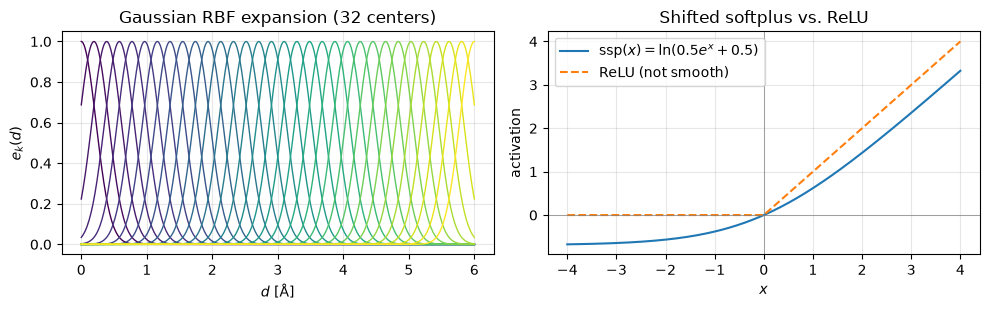

In [3]:
# Create a uniform grid of distances
d = torch.linspace(0, 6.0, 400)

# Evaluate the Gaussian RBF on the grid
# (400, 32)
E_k = rbf(d)

# Visualize the shifted softplus and Gaussian RBF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
colors = plt.get_cmap("viridis")(np.linspace(0, 1, E_k.shape[1]))  # sequential: ordered centers
for k in range(E_k.shape[1]):
    ax1.plot(d, E_k[:, k], color=colors[k], lw=1)
ax1.set_xlabel(r"$d$ [Å]")
ax1.set_ylabel(r"$e_k(d)$")
ax1.set_title("Gaussian RBF expansion (32 centers)")
ax1.grid(True, alpha=0.3)

# Create a uniform grid of x values for the shifted softplus and ReLU
x = torch.linspace(-4, 4, 400)

# Visualize the shifted softplus and ReLU
ax2.plot(x, ssp(x), label=r"ssp$(x)=\ln(0.5e^x+0.5)$")
ax2.plot(x, nn.functional.relu(x), "--", label="ReLU (not smooth)")
ax2.axhline(0, color="gray", lw=0.5)
ax2.axvline(0, color="gray", lw=0.5)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel("activation")
ax2.set_title("Shifted softplus vs. ReLU")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig.tight_layout()

### The filter-generating network

The expanded distance is fed through **two dense layers with (shifted) softplus
activations** to produce the filter values:

$$
W(d_{ij}) = \mathrm{ssp}\Big( W_2\, \mathrm{ssp}\big( W_1\, e(d_{ij}) + b_1 \big) + b_2 \Big) \in \mathbb{R}^F .
$$

In this course, we slightly modify this network by multiplying the filter by a
smooth cosine cutoff from Lesson 05b,

$$
f_\mathrm{cut}(d) = \tfrac{1}{2}\Big(\cos\big(\pi d / r_\mathrm{cut}\big) + 1\Big) \qquad \text{where} \qquad d < r_\mathrm{cut}.
$$

We perform this modification so that the resulting filters and the energy
*smoothly* go to zero when a neighbor crosses the graph cutoff. Note that the
original SchNet paper had no explicit cutoff (its RBF grid covered all distances
in the specified range). Using the cutoff became a standard in the authors'
later SchNetPack implementation. Without the cutoff, atoms entering/leaving the
radius graph would create small discontinuities in the potential energy surface
as discussed in detail in [Lesson 05b](05b_radial_basis_and_cutoffs.ipynb).

In [4]:
# Create a filter-generating network that takes distances and outputs filters
class FilterNet(nn.Module):
    '''W(d): distance -> R^F filter, RBF expansion + 2 dense layers + smooth cutoff.'''
    
    def __init__(self, n_features: int, r_cut: float, n_rbf: int = 32):
        super().__init__()

        # Gaussian RBF expansion of the distance
        self.rbf = GaussianRBF(r_cut, n_rbf)
        
        # Two dense layers
        self.dense1 = nn.Linear(n_rbf, n_features)
        self.dense2 = nn.Linear(n_features, n_features)
        
        # Cutoff distance for the smooth cosine cutoff
        self.r_cut = r_cut
    
    # (E,) -> (E, F)
    def forward(self, d):
        # Compute the filter values W(d) = ssp(W2 ssp(W1 e(d) + b1) + b2)
        W = ssp(self.dense2(ssp(self.dense1(self.rbf(d)))))
        
        # Smooth cutoff function f_cut(d) = 0.5 * (cos(pi d / r_cut) + 1)
        # Lesson 05b
        f_cut = 0.5 * (torch.cos(np.pi * d / self.r_cut) + 1.0)
        
        # Multiply the filter by the smooth cutoff so that it goes to zero
        # smoothly at r_cut
        return W * f_cut.unsqueeze(-1)

# Test the filter-generating network
W_test = FilterNet(n_features=64, r_cut=6.0)(torch.tensor([3.0, 5.999]))
print("filter shape:", W_test.shape, "| filter at d≈r_cut ~ 0:", W_test[1].abs().max().item())

filter shape: torch.Size([2, 64]) | filter at d≈r_cut ~ 0: 5.137263059395991e-09


## The atom-wise layers

The **Atom-wise layers** are dense layers applied to each atom's feature vector
separately, with weights shared across atoms:

$$
x_i^{l+1} = W^l x_i^l + b^l .
$$

They recombine feature channels (which the feature-wise cfconv deliberately does
not) and keep the parameter count independent of the number of atoms.

## The Interaction block

Each block updates atoms through a residual connection

$$
x_i^{l+1} = x_i^l + v_i^l,
$$

where the residual $v_i^l$ is computed as: atom-wise layer $\to$ cfconv $\to$
atom-wise layer $\to$ ssp $\to$ atom-wise layer. In the code block below, each
line is tagged with the component it implements.

In [5]:
class CFConv(nn.Module):
    '''Continuous-filter convolution:  x_i' = sum_{j in N(i)} x_j \\odot W(d_ij).'''
    
    def __init__(self, n_features: int, r_cut: float):
        super().__init__()
        # Create a filter-generating network that takes distances and outputs filters
        self.filter_net = FilterNet(n_features, r_cut)
    
    def forward(self, x, edge_index, d):
        # Receiver i, sender j  (05a convention)
        i, j = edge_index
        
        # x_j \\odot W(d_ij): Element-wise
        messages = x[j] * self.filter_net(d)
        
        # sum_j -> atom i
        return torch.zeros_like(x).index_add_(0, i, messages)

class InteractionBlock(nn.Module):
    '''x_i <- x_i + v_i with v_i = aw3( ssp( aw2( cfconv( aw1(x) ) ) ) )'''
    
    def __init__(self, n_features: int, r_cut: float):
        super().__init__()
        self.aw1 = nn.Linear(n_features, n_features)   # Atom-wise
        self.cfconv = CFConv(n_features, r_cut)        # Continuous-filter convolution
        self.aw2 = nn.Linear(n_features, n_features)   # Atom-wise
        self.aw3 = nn.Linear(n_features, n_features)   # Atom-wise
        
    def forward(self, x, edge_index, d):
        # Compute the interaction
        v = self.aw3(ssp(self.aw2(self.cfconv(self.aw1(x), edge_index, d))))
        
        # Residual connection
        return x + v

## The full SchNet

It is time to implement the full SchNet architecture with its paper's
hyperparameters $F = 64$ features and $T = 3$ interaction blocks. Our
implementation will involve the following three main components:

1. **Embedding**: Wach atom starts from a learned vector depending only on its
   nuclear charge, $x_i^0 = a_{Z_i} \in \mathbb{R}^F$. (Our dataset is pure
   argon. So, this is a single learned vector. Regardless, we keep the layer to
   allow the model to generalize to mixtures.)
2. **$T$ interaction blocks**: We use these interaction units *without* weight
   sharing across blocks.
3. **Atom-wise readout**: The atom-wise layers change the feature dimension from
   $F \to F/2 \to 1$, with an ssp in between, producing per-atom energies $E_i$.
   These energies are **sum-pooled** into the total energy in the final layer:

$$
\hat E = \sum_{i=1}^{n} E_i,
$$

where $n$ is the number of atoms in the system. Sum pooling makes the prediction
*extensive*: doubling a system of non-interacting halves doubles $\hat E$,
exactly as a physical energy must.

In [6]:
# SchNet model: Embedding -> T interaction blocks -> Readout
class SchNet(nn.Module):
    def __init__(self, n_features: int = 64, n_interactions: int = 3,
                 r_cut: float = 6.0, n_species: int = 1):
        super().__init__()
        self.embedding = nn.Embedding(n_species, n_features)          # x_i^0 = a_{Z_i}
        self.interactions = nn.ModuleList(
            [InteractionBlock(n_features, r_cut) for _ in range(n_interactions)])
        self.readout1 = nn.Linear(n_features, n_features // 2)        # atom-wise F -> F/2
        self.readout2 = nn.Linear(n_features // 2, 1)                 # atom-wise F/2 -> 1
        self.r_cut = r_cut

    def forward(self, pos, species, edge_index, batch, n_graphs):
        i, j = edge_index
        d = (pos[j] - pos[i]).norm(dim=-1)                            # d_ij (invariant input!)
        x = self.embedding(species)                                   # Embedding
        for block in self.interactions:                               # T interaction blocks
            x = block(x, edge_index, d)
        E_i = self.readout2(ssp(self.readout1(x))).squeeze(-1)        # Per-atom energies
        E = torch.zeros(n_graphs, dtype=pos.dtype, device=pos.device) # Container for per-graph energies
        return E.index_add_(0, batch, E_i)                            # Sum-pool: E = sum_i E_i

# Initialize the SchNet model and move it to the appropriate device (CPU or GPU)
model = SchNet().to(device)

# Print the total number of parameters in the SchNet model
print("SchNet parameters:", sum(p.numel() for p in model.parameters()))

SchNet parameters: 58433


## Calculating forces from the energy

Physical forces are the negative gradient of the potential energy:

$$
\vec F_i(Z_1,\dots,Z_n, \vec r_1,\dots,\vec r_n) \;=\; -\,\frac{\partial \hat E}{\partial \vec r_i}(Z_1,\dots,Z_n,\vec r_1,\dots,\vec r_n),
$$

where $\vec F_i$ is the force on atom $i$, $Z_i$ is the nuclear charge of atom
$i$, and $\vec r_i$ is the position of atom $i$.

There are multiple reasons why we don't just predict forces directly with a
second output head:

1. **Energy conservation:** A force field must be *conservative*: the work
   $\oint \vec F \cdot \mathrm{d}\vec r$ around any closed loop must vanish,
   otherwise one could drive atoms in circles and gain energy forever. Gradients
   of a scalar are conservative *by construction* (curl of a gradient is zero).
   On the contrary, a free-form predicted vector field is not conservative, and
   in molecular dynamics simulations, its non-conservative part pumps energy
   into or out of the system which can lead to unphysical behavior.

2. **Consistency:** A separate force head can contradict the energy head whereas
   the gradient force is exactly the derivative of the energy the model actually
   predicts.
   
3. **Equivariance for free:** Let $X \in \mathbb{R}^{N \times 3}$ denote the
   position matrix of the atoms and, $X' = RX + \vec t$, is its image under a
   rigid motion. This means, for each atom $k$, $\vec r_k' = R\,\vec r_k + \vec
   t$. Hence, $\partial \vec r_k'/\partial \vec r_i = R\,\delta_{ki}$. Since our
   $\hat E$ is invariant (scalar): 
   
   $$
   \hat E(X') = \hat E(X) \qquad \forall\, R \in O(3) \quad \text{and} \quad \vec t \in \mathbb{R}^3.
   $$
   
   Differentiating both sides of this identity with respect to $\vec r_i$ (using
   the chain rule on the left-hand side) yields:

   $$
   \frac{\partial}{\partial \vec r_i}\,\hat E(X')
   = \sum_{k} \Big(\frac{\partial \vec r_k'}{\partial \vec r_i}\Big)^{\!\top}
   (\nabla_{k}\hat E)(X')
   = R^\top\, (\nabla_{i}\hat E)(X')
   \;\stackrel{!}{=}\; (\nabla_i \hat E)(X),
   $$

   where $(\nabla_i \hat E)(X')$ denotes the gradient of $\hat E$ with respect
   to its $i$-th position argument, *evaluated at the transformed configuration*
   $X'$. Negating both sides of the the last equality, multiplying it by $R$
   from the left, and recalling, $R R^\top = I$, yields

   $$
   (\nabla_i \hat E)(X') = R\, (\nabla_i \hat E)(X)
   \quad\Longrightarrow\quad
   \vec F_i(RX + \vec t\,) = R\, \vec F_i(X).
   $$

   As such, the forces should automatically **co-rotate with the molecule** and
   flip sign under parity, like any polar vector; no extra machinery needed.

In the code block below, $-\partial\hat E/\partial \vec r_i$ translates to one
call to `torch.autograd.grad`. During training we keep the compute graph by
setting the `create_graph=True`. So, the *force error itself* can be
back-propagated: this is why the model must be twice differentiable.

In [7]:
# Define a function to compute energy and forces using autograd
def energy_and_forces(model, pos, species, edge_index, batch, n_graphs, create_graph=False):
    '''E and F = -dE/dpos via autograd (paper Eq. (4)).'''
    
    # Enable gradient computation for the positions
    pos = pos.requires_grad_(True)
    
    # Compute the energy using the model
    E = model(pos, species, edge_index, batch, n_graphs)
    
    # Calculate the foces: F_i = -dE/dr_i
    (dE_dpos,) = torch.autograd.grad(E.sum(), pos, create_graph=create_graph)
    
    # Return the energy and the negative gradient (forces)
    return E, -dE_dpos

# Create random positions for 8 atoms, scaled by a factor of 3.0
pos0 = torch.randn(8, 3, device=device) * 3.0

# Create a radius graph for the positions with a cutoff of 6.0
ei0 = radius_graph(pos0.cpu(), r_cut=6.0).to(device)

# Create zero tensors for species and batch indices for the 8 atoms
z0 = torch.zeros(8, dtype=torch.long, device=device)
b0 = torch.zeros(8, dtype=torch.long, device=device)

# Compute the energy and forces for the random positions using the SchNet model
E0, F0 = energy_and_forces(model, pos0, z0, ei0, b0, 1)

# Print the shapes of the computed energy and forces tensors
print("E shape:", tuple(E0.shape), "| F shape:", tuple(F0.shape))

E shape: (1,) | F shape: (8, 3)


## The Lennard-Jones argon dataset

We train the SchNet model on the course's own local toy dataset
(`course_utils.data.make_lj_argon_dataset`) coming from a short Langevin MD
simulation run at 300 K of **8 argon atoms** interacting via a Lennard-Jones
potential ($\varepsilon = 0.0104$ eV, $\sigma = 3.4$ Å) using ASE. Each frame
carries positions (Å), total energy (eV) and forces (eV/Å). We take 200 frames
and split them into **150 train / 50 validation** groups.

Before training, we perform **energy standardization** by subtracting the mean
per-atom energy of the training set, $\bar\varepsilon$, from the total energy
$E$:

$$
\tilde E = E - n\,\bar\varepsilon, \qquad
\bar\varepsilon = \frac{1}{|\mathcal{D}_\mathrm{train}|}\sum_{\text{frames}} \frac{E}{n},
$$

where $n$ is the number of atoms in the frame. Why? a freshly initialized
network outputs $\approx 0$, while raw energies sit at a large constant offset;
without the shift, the first phase of training just learns a constant, and the
loss is dominated by it. Making the shift **per-atom** (not per-frame) keeps the
target extensive. So, the same shift would remain correct for systems of
different sizes. Regardless of the standardization method, the forces remain
untouched because $\partial (n\bar\varepsilon)/\partial \vec r_i = 0$, a
constant shift has zero gradient.

In [8]:
# Generate a dataset of 200 frames of Lennard-Jones Argon
frames = make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)

# Split the dataset into training and validation sets
train_frames, val_frames = train_val_split(frames, val_fraction=0.25, seed=0)

# Get the number of atoms from the first frame's position tensor
n_atoms = frames[0]["pos"].shape[0]

# Get the energies of the training frames
E_train = np.array([f["energy"] for f in train_frames])

# Compute the mean per-atom energy (for training only)
eps_bar = E_train.mean() / n_atoms

# Print the stats
print(f"{len(train_frames)} train / {len(val_frames)} val frames, {n_atoms} atoms each")
print(f"per-atom shift  eps_bar = {eps_bar:.6f} eV")
print(f"E fluctuations: std = {E_train.std()*1e3:.2f} meV | "
      f"F std = {torch.stack([f['forces'] for f in train_frames]).std()*1e3:.2f} meV/Å")

150 train / 50 val frames, 8 atoms each
per-atom shift  eps_bar = -0.009446 eV
E fluctuations: std = 21.30 meV | F std = 32.39 meV/Å


We now create a convenience function to merge frames into disconnected graphs
and batch them for training and validation.

In [9]:
R_CUT = 6.0

def make_batch(frame_list, device):
    '''Merge frames into one disconnected graph: pos, species, edge_index, batch, E~, F.'''
    
    pos, species, edges, batch, E, F = [], [], [], [], [], []
    offset = 0
    for g, f in enumerate(frame_list):
        # Extract positions
        p = f["pos"].float()
        pos.append(p)
        
        # Create a tensor of zeros for species (all argon atoms)
        species.append(torch.zeros(len(p), dtype=torch.long))
        
        # Create a radius graph for the positions with a cutoff of R_CUT and
        # apply an offset
        edges.append(radius_graph(p, R_CUT) + offset)
        
        # Create a tensor for the batch indices, where all atoms in the current
        # frame belong to graph g
        batch.append(torch.full((len(p),), g, dtype=torch.long))
        
        # Standardization: Per-atom mean shift
        E.append(f["energy"] - len(p) * eps_bar)
        
        # Extract forces and convert to float
        F.append(f["forces"].float())
        
        # Update the offset for the next frame by adding the number of atoms in
        # the current frame
        offset += len(p)
    
    # Concatenate all the lists into single tensors and move them to the
    # specified device
    return (torch.cat(pos).to(device), torch.cat(species).to(device),
            torch.cat(edges, dim=1).to(device), torch.cat(batch).to(device),
            torch.tensor(E, dtype=torch.float32, device=device), torch.cat(F).to(device))

# Create batches for training and validation frames
train_batch = make_batch(train_frames, device)
val_batch   = make_batch(val_frames, device)
print("train graph:", train_batch[0].shape[0], "atoms,", train_batch[2].shape[1], "edges")

train graph: 1200 atoms, 4044 edges


## Training with energies and forces

It is time to define the loss function. The original SchNet manuscript uses a a
weighted sum of the energy and force errors:

$$
\ell\big(\hat E, (E, \vec F_1, \dots, \vec F_n)\big)
= \rho\, \big\lVert E - \hat E \big\rVert^2
+ \frac{1}{n}\sum_{i=1}^{n} \Big\lVert \vec F_i - \Big(-\frac{\partial \hat E}{\partial \vec R_i}\Big) \Big\rVert^2 ,
$$

where $E, \vec F_i$ are the reference energy and forces, $\hat E$ the model
energy, and the hyperparameter $\rho$ balances the impact of two terms during
optimization. The manuscript uses $\rho = 0.01$, which the authors optimized
empirically, to account for the different scales of the energy and forces. The
magnitude of raw energies in the original SchNet training dataset are huge
compared to those of their corresponding forces. After our per-atom
standardization, the energy fluctuations (tens of meV) and force components
(tens of meV/Å) have *similar* scales. So, we can set $\rho = 1$ for our toy
dataset.

Why do we train on forces after all? Each frame carries **one** energy label but
$3n$ force labels, and forces probe the local *shape* of the potential energy
surface (as gradients of the energy). In the SchNet manuscript, adding forces at
$n{=}1000$ training frames improves energies more than going to $n{=}50{,}000$
frames with energies alone. Our dataset, however, is tiny (< 1000 frames). So,
we do simple **full-batch** gradient descent with Adam optimizer.

Let us implement the loss function and the training loop.

In [10]:
# Define a function to evaluate the mean absolute error (MAE) for energy and forces
def eval_mae(model, batch):
    '''(energy MAE per atom [meV/atom], force MAE [meV/Å]).'''
    
    # Unpack the batch into its components
    pos, species, edge_index, bvec, E_ref, F_ref = batch
    
    # Compute the energy and forces using the model
    E, F = energy_and_forces(model, pos, species, edge_index, bvec, len(E_ref))
    
    # Calculate the mean absolute error (MAE) for energy and forces
    e_mae = (E - E_ref).abs().mean().item() / n_atoms * 1e3
    f_mae = (F - F_ref).abs().mean().item() * 1e3
    return e_mae, f_mae

# Define a loss function that combines energy and force errors
def loss_fn(E, F, E_ref, F_ref, rho=1.0):
    '''Eq. (5): rho * ||E - E^||^2  +  (1/n) sum_i ||F_i - F^_i||^2   (mean over frames).'''
    
    # Compute the mean squared error (MSE) for energy and forces
    loss_E = ((E_ref - E) ** 2).mean()
    loss_F = ((F_ref - F) ** 2).sum(dim=-1).mean() * 3.0   # (1/n) sum_i |.|^2 per frame
    
    # Return the combined loss as a weighted sum of energy and force losses
    return rho * loss_E + loss_F

In [11]:
# Set up the optimizer, learning rate scheduler, and history tracking for
# training
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=600)
history = {"train E MAE [meV/atom]": [], "val E MAE [meV/atom]": [],
           "train F MAE [meV/Å]": [], "val F MAE [meV/Å]": []}

# Unpack the training batch into its components
pos, species, edge_index, bvec, E_ref, F_ref = train_batch

# Start the training loop for 600 epochs
t0 = time.time()
for epoch in range(1, 600 + 1):
    model.train(); optimizer.zero_grad()
    # Keep the compute graph: d(loss_F)/dpos
    E, F = energy_and_forces(model, pos, species, edge_index, bvec,
                             len(E_ref), create_graph=True)
    loss = loss_fn(E, F, E_ref, F_ref, rho=1.0)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    # Evaluation of training and validation MAE for energy and forces
    tr = eval_mae(model, train_batch)
    va = eval_mae(model, val_batch)
    for key, v in zip(history, (tr[0], va[0], tr[1], va[1])):
        history[key].append(v)
    if epoch % 100 == 0 or epoch == 599:
        print(f"epoch {epoch:4d}  loss {loss.item():.3e}   "
              f"val E MAE {va[0]:7.3f} meV/atom   val F MAE {va[1]:7.3f} meV/Å")
        
# Print the training time
print(f"training time: {time.time() - t0:.1f} s on {device}")

epoch  100  loss 1.842e-04   val E MAE   0.449 meV/atom   val F MAE   2.452 meV/Å
epoch  200  loss 1.428e-05   val E MAE   0.156 meV/atom   val F MAE   0.774 meV/Å
epoch  300  loss 9.810e-06   val E MAE   0.129 meV/atom   val F MAE   0.670 meV/Å
epoch  400  loss 8.453e-06   val E MAE   0.121 meV/atom   val F MAE   0.635 meV/Å
epoch  500  loss 8.042e-06   val E MAE   0.118 meV/atom   val F MAE   0.624 meV/Å
epoch  599  loss 7.982e-06   val E MAE   0.118 meV/atom   val F MAE   0.622 meV/Å
epoch  600  loss 7.982e-06   val E MAE   0.118 meV/atom   val F MAE   0.622 meV/Å
training time: 14.9 s on cuda


Let's visualize the training and validation mean absolute errors (MAEs) for
energy and forces. 

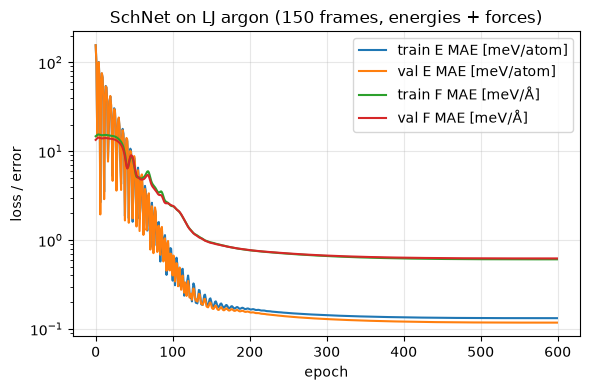

In [12]:
# Use the convenient plotting function from course_utils
ax = plot_training_curves(history)

# Configure the plot with a title and adjust the layout
ax.set_title("SchNet on LJ argon (150 frames, energies + forces)")
ax.figure.tight_layout()

### Force parity plot

Let us now draw a *parity plot* which compares the predicted forces against the
reference ones. In this plot, a perfect model should lie on the diagonal. We
flatten all $3n$ force components of every validation frame.

final validation:  E MAE = 0.118 meV/atom   |   F MAE = 0.622 meV/Å


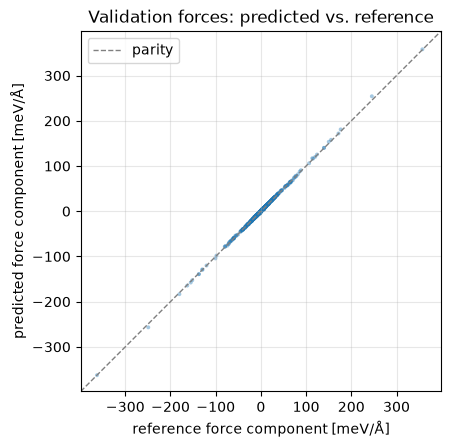

In [13]:
# Set the model to evaluation mode
model.eval()

# Get the predicted and reference forces in meV/Å
_, F_val = energy_and_forces(model, *val_batch[:4], len(val_batch[4]))
F_pred = F_val.detach().cpu().numpy().ravel() * 1e3
F_true = val_batch[5].cpu().numpy().ravel() * 1e3

# Visualize the predicted forces against the reference forces
fig, ax = plt.subplots(figsize=(4.6, 4.6))
lim = np.abs(F_true).max() * 1.1
ax.plot([-lim, lim], [-lim, lim], "--", color="gray", lw=1, label="parity")
ax.scatter(F_true, F_pred, s=8, alpha=0.4, color="C0", edgecolors="none")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("reference force component [meV/Å]")
ax.set_ylabel("predicted force component [meV/Å]")
ax.set_title("Validation forces: predicted vs. reference")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

# Evaluate the final mean absolute error (MAE) for energy and forces on the
# validation set
e_mae, f_mae = eval_mae(model, val_batch)
print(f"final validation:  E MAE = {e_mae:.3f} meV/atom   |   F MAE = {f_mae:.3f} meV/Å")

## Numerical verification: invariant energy, covariant forces

We now *test* the claims of Sections 1 and 5 with the course harness (`course_utils.equivariance`), in float64 to separate genuine symmetry breaking from round-off:

- **Energy** transforms as the trivial irrep `0e`:  $\hat E(RX + \vec t\,) = \hat E(X)$ for random $R \in O(3)$ (rotations *and* improper rotations, i.e. parity) and translations $\vec t$.
- **Forces** transform as vectors `1o`:  $\vec F(RX + \vec t\,) = R\, \vec F(X)$.

The wrapper functions rebuild the radius graph from the transformed positions, so the test covers the whole pipeline (graph construction included), not just the network.

*A numerical footnote:* for $l=1$ outputs the harness compares against `o3.Irreps("1o").D_from_matrix(R)`, and e3nn's matrix $\to$ Euler angles $\to$ Wigner-D conversion is itself only accurate to $\sim 10^{-7}$ — that (not the model) limits the tolerance of the harness check. Since for $l = 1$ the Wigner D-matrix *is* the rotation matrix itself, we add a direct check $\vec F(RX + \vec t\,) = R\,\vec F(X)$ against $R$, which passes at full float64 precision.

In [14]:
model64 = copy.deepcopy(model).double().cpu().eval()
pos_test = val_frames[0]["pos"].clone()                      # float64 positions, (8, 3)
z_test = torch.zeros(n_atoms, dtype=torch.long)
b_test = torch.zeros(n_atoms, dtype=torch.long)

def energy_fn(pos):                                          # pos -> E, shape (1,): irrep 0e
    edge_index = radius_graph(pos, R_CUT)                    # graph rebuilt after transform
    return model64(pos, z_test, edge_index, b_test, 1).reshape(1)

def force_fn(pos):                                           # pos -> F, shape (n, 3): irrep 1o
    edge_index = radius_graph(pos.detach(), R_CUT)
    _, F = energy_and_forces(model64, pos, z_test, edge_index, b_test, 1)
    return F

print("energy  E(RX + t) = E(X):")
assert_model_equivariant(energy_fn, pos_test, "0e", tol=1e-12)
print("forces  F(RX + t) = R F(X)  (harness; tol limited by e3nn's D_from_matrix ~1e-7):")
assert_model_equivariant(force_fn, pos_test, "1o", tol=1e-6)

energy  E(RX + t) = E(X):
equivariant!  (max error 1.388e-16 over random O(3) + translations elements)
forces  F(RX + t) = R F(X)  (harness; tol limited by e3nn's D_from_matrix ~1e-7):
equivariant!  (max error 7.182e-09 over random O(3) + translations elements)


7.1820787346868475e-09

In [15]:
# Direct check against R itself (for l=1, the Wigner D *is* the rotation matrix):
from e3nn import o3
err = 0.0
F_ref = force_fn(pos_test)
for _ in range(5):
    R = o3.rand_matrix(dtype=torch.float64)
    if torch.rand(()) < 0.5:
        R = -R                                              # improper rotation: parity test
    t = torch.randn(3, dtype=torch.float64)
    err = max(err, (force_fn(pos_test @ R.T + t) - F_ref @ R.T).abs().max().item())
assert err < 1e-12, err
print(f"forces exactly covariant: max |F(RX+t) - R F(X)| = {err:.3e}  (float64)")

forces exactly covariant: max |F(RX+t) - R F(X)| = 1.284e-16  (float64)


## Summary

- **Distances are E(3)-invariant** (rotations, translations, *and* parity), so any network built on $\{Z_i, d_{ij}\}$ predicts invariant energies by construction — no representation theory needed.
- **SchNet** = atom-type embedding (Eq. 3) → interaction blocks, each: atom-wise → cfconv (Eq. 2: $\sum_j x_j \circ W(d_{ij})$, filters generated from a Gaussian-RBF distance expansion by a small ssp-MLP) → atom-wise → ssp → atom-wise, with a residual connection → atom-wise readout, sum-pooled to $\hat E$.
- **Forces come from autograd**, $\vec F_i = -\partial\hat E/\partial\vec r_i$ (Eqs. 1/4): conservative by construction, consistent with the energy, and automatically covariant ($\vec F(RX) = R\vec F(X)$ — verified numerically at $\sim 10^{-13}$).
- Training with the **combined loss** (Eq. 5) exploits the $3n$ force labels per frame; we standardized energies by a per-atom mean shift so the network doesn't waste time learning a constant.

**Next:** distance-only models are provably *incomplete* — Lesson 07b (`07b_dimenet.ipynb`) shows environments they cannot distinguish and adds **angles** via directional message passing (DimeNet).

## Exercises

**1. Energy-only training.** Retrain with the force term removed (set its weight to zero, keep $\rho = 1$). How do the validation force errors compare? Relate your finding to Table 2 of the SchNet paper.

<details><summary>Solution</summary>

Set `loss = rho * loss_E` (or add a `force_weight=0.0` factor). Energy MAE stays reasonable, but force MAE degrades by a large factor: the model matches energies of the 150 training geometries without matching the *slope* of the PES between them. This mirrors the paper's Table 2, where SchNet trained on energies alone at $N{=}1000$ has force errors an order of magnitude worse than the energy+force model — and why every modern interatomic potential trains on forces. </details>

**2. Break the smoothness.** Replace `ssp` by `torch.relu` in `FilterNet` and the readout, and retrain. What happens to the force loss and the parity plot? Why is this expected?

<details><summary>Solution</summary>

Training still runs (autograd differentiates ReLU almost everywhere), but forces become piecewise-constant functions of the inputs with jumps, and training on the force loss needs *second* derivatives, which are zero almost everywhere for ReLU — gradients of the force term stop flowing through the filter shape, so the force fit stalls/roughens. This is exactly why SchNet chose the $C^\infty$ shifted softplus (Sec. 4.2). </details>

**3. Remove the cutoff function.** Delete the `f_cut` factor in `FilterNet` and evaluate the trained model's energy while moving one atom smoothly from 5.8 Å to 6.2 Å away from another. Plot $\hat E$ vs. distance. What do you see at 6 Å, and why does it matter for MD?

<details><summary>Solution</summary>

Without $f_\mathrm{cut}$, the energy jumps discontinuously when the pair crosses $r_\mathrm{cut}$: the edge vanishes from the radius graph while its filter value is still non-zero. The force (the derivative) is undefined/infinite at the jump; in MD this kicks atoms unphysically and destroys energy conservation. With $f_\mathrm{cut}$ the contribution vanishes smoothly (value and derivative → 0 at $r_\mathrm{cut}$). </details>

## Reference 

Schütt et al., *SchNet: A continuous-filter convolutional neural network for modeling quantum interactions* arXiv.1706.08566 (2017), Eqs. (1)–(5) — [Schütt et al. (2017)](https://arxiv.org/pdf/1706.08566). An extended version is Schütt et al., *SchNet — a deep learning architecture for molecules and materials*, J. Chem. Phys. **148**, 241722 (2018).